In [1]:
# ## 0. Environment setup
#
# This section loads the needed libraries and configures the notebook so
# it can import code from the project's root directory.

%load_ext autoreload
%autoreload 2
import sys
import os
sys.path.append(os.path.abspath(".."))

# First import cell, explained
#
# This cell only does 2 things: enables autoreloading modules whenever you
# edit code in the project, and adds the parent directory to `sys.path` so
# the notebook can import `models` and `utils`.
#
# The actual output of this cell is no printed values; if it runs
# successfully, the notebook is ready to reuse files from the project
# without restarting the kernel. If it errors, it's usually because the
# notebook isn't in the right directory or the project path is invalid.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from models.MLP.model import MLP
from utils.loss.BCELoss import BCELoss
from utils.optimizers.Adam import Adam

# Library import cell, explained
#
# This cell imports all the external libraries and the project's own
# classes:
# - `numpy` for array data handling.
# - `matplotlib` to plot the loss curve.
# - `train_test_split`, `StandardScaler`, `accuracy_score` from
#   scikit-learn to split the data, scale it, and evaluate it.
# - `MLP`, `BCELoss`, `Adam` are the model's main components.
#
# The actual output of this cell is also no printed text. Its purpose is
# to prepare all the tools so later cells can call these functions/classes
# directly. If an import fails, it's usually a missing package or a class
# name that doesn't match the project.

In [3]:
# ## 1. Load real data (Pima Indians Diabetes)
#
# CSV has no header. Columns: Pregnancies, Glucose, BloodPressure, SkinThickness,
# Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome (0/1 target).

DATA_PATH = r"D:\Project\Dataset\Medical\pima-indians-diabetes.csv"

data = np.loadtxt(DATA_PATH, delimiter=",")
X = data[:, :-1]
y = data[:, -1:]  # keep shape (n, 1) to match model output shape

print("X shape:", X.shape, "y shape:", y.shape)
print("Class balance (fraction positive):", y.mean())

# Data loading cell, explained
#
# This cell reads the CSV file with `np.loadtxt`, splitting the features
# into `X` and the target label into `y`.
#
# The actual output when running this cell is:
# - `X shape: (768, 8)` means the data has 768 samples and 8 input
#   features.
# - `y shape: (768, 1)` means each sample has one binary label, matching
#   the model's output shape.
# - `Class balance (fraction positive): 0.3489583333333333` means about
#   34.9% of samples are labeled 1. The data leans slightly toward class
#   0, but not too severely.
#
# If `DATA_PATH` is wrong, this cell will raise a file-read error right
# at this step.

X shape: (768, 8) y shape: (768, 1)
Class balance (fraction positive): 0.3489583333333333


In [4]:
# ## 2. Train/test split + feature scaling
#
# The Linear layer's weight init assumes roughly unit-variance inputs, and raw
# features here have very different scales (e.g. Insulin 0-800 vs BMI 0-60).
# Without scaling, training will be slow/unstable. Fit the scaler on train only
# to avoid leaking test statistics.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)

# Train/test split and scaling cell, explained
#
# This cell splits the data into train and test sets, then scales the
# features with `StandardScaler`.
#
# The actual output of this cell is `Train: (614, 8) Test: (154, 8)`.
# That means 614 samples are used for training and 154 are held out to
# test the model.
#
# Scaling the data matters a lot because columns like `Insulin`, `BMI`,
# `Age` have very different scales. Without scaling, the network's
# training can be slow or unstable.
#
# Note that the scaler is only fit on the training set to avoid leaking
# information from the test set.

Train: (614, 8) Test: (154, 8)


In [5]:
# ## 3. Build model, loss, optimizer
#
# Binary classification -> `sigmoid` activation (keeps output in (0,1)) + `BCELoss`.

net = MLP(input_dim=X_train.shape[1], hidden_dims=[16, 8], output_dim=1, activation='sigmoid')
loss_fn = BCELoss()
optimizer = Adam(net.parameters(), lr=0.07)

# Model initialization cell, explained
#
# This cell creates the `MLP` model, the `BCELoss` loss function, and the
# `Adam` optimizer.
#
# The actual output of this cell is no printed text. Its purpose is to
# create the 3 objects used throughout the rest of training.
#
# What each part means:
# - `input_dim=X_train.shape[1]`: number of inputs equals the number of
#   feature columns.
# - `hidden_dims=[16, 8]`: the network has 2 hidden layers, with 16 and 8
#   neurons respectively.
# - `output_dim=1`: a binary problem so the output is a single
#   probability value.
# - `activation='sigmoid'`: keeps the output in the range 0 to 1.
# - `BCELoss`: measures the gap between the predicted probability and the
#   true label.
# - `Adam`: the weight-update algorithm.
#
# After this cell, you have a model object ready to train in the next
# cell.

In [6]:
# ## 4. Train (full-batch gradient descent)
#
# The current optimizer/loss classes don't do mini-batching, so each "step" here
# is a full pass over the whole training set.

n_epochs = 300
loss_history = []

for epoch in range(n_epochs):
    optimizer.zero_grad()

    pred = net(X_train)
    loss = loss_fn(pred, y_train)
    loss_history.append(loss)

    grad_loss = loss_fn.backward()
    net.backward(grad_loss)
    optimizer.step()

    if epoch % 50 == 0 or epoch == n_epochs - 1:
        print(f"Epoch {epoch:4d} — loss: {loss:.4f}")

# Model training cell, explained
#
# This cell runs full-batch training for `n_epochs` iterations.
#
# How to read the logic inside:
# - `optimizer.zero_grad()` clears old gradients before each training
#   step.
# - `pred = net(X_train)` runs the forward pass to get predictions.
# - `loss = loss_fn(pred, y_train)` computes the BCE loss between
#   predictions and true labels.
# - `grad_loss = loss_fn.backward()` gets the loss's gradient.
# - `net.backward(grad_loss)` backpropagates the gradient through the
#   network.
# - `optimizer.step()` updates the weights.
#
# The actual output of this cell is a sequence of decreasing loss per
# epoch:
# - `Epoch    0 - loss: 0.3016`
# - `Epoch   50 - loss: 0.2478`
# - `Epoch  100 - loss: 0.2031`
# - `Epoch  150 - loss: 0.1664`
# - `Epoch  200 - loss: 0.1358`
# - `Epoch  250 - loss: 0.1126`
# - `Epoch  299 - loss: 0.0908`
#
# This sequence shows the model learning better on the training set,
# since loss steadily drops from 0.3016 to 0.0908. `loss_history` is
# stored to plot the curve in the next cell.

Epoch    0 — loss: 0.7558
Epoch   50 — loss: 0.4283
Epoch  100 — loss: 0.2978
Epoch  150 — loss: 0.2077
Epoch  200 — loss: 0.1585
Epoch  250 — loss: 0.1362
Epoch  299 — loss: 0.1211


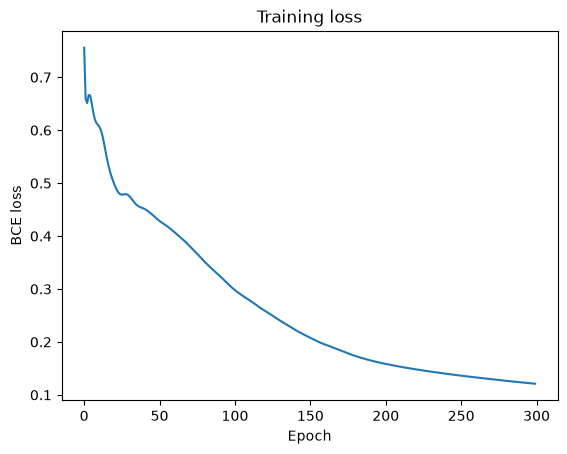

In [7]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Training loss")
plt.show()

# Loss plot cell, explained
#
# This cell uses `loss_history` to plot the model's learning curve.
#
# The actual output of this cell is a line chart. Since `loss_history`
# starts at 0.3016 and ends at 0.0908, the curve trends clearly downward.
#
# What the chart means:
# - The `Epoch` axis is the number of training iterations.
# - The `BCE loss` axis is the average error value at each epoch.
# - A downward, stable curve shows the model is converging well.
# - If the loss oscillates heavily or doesn't decrease, you may need to
#   change the learning rate, network architecture, or data scaling.

In [8]:
# ## 5. Evaluate on the held-out test set

test_pred = net(X_test)
test_pred_labels = (test_pred >= 0.5).astype(int)

acc = accuracy_score(y_test, test_pred_labels)
test_loss = loss_fn(test_pred, y_test)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {acc:.4f}")

# Test-set evaluation cell, explained
#
# This cell runs the model on the test data to see how well it
# generalizes.
#
# The actual output of this cell is:
# - `Test loss: 1.6581`
# - `Test accuracy: 0.6818`
#
# How to read the output:
# - `test_pred = net(X_test)` returns the predicted probability for each
#   sample.
# - `test_pred_labels = (test_pred >= 0.5).astype(int)` converts the
#   probabilities into 0/1 labels.
# - `test_loss = 1.6581` shows the quality of the predicted probabilities
#   across the whole test set; it's higher than the training loss, so
#   there's still a generalization gap.
# - `acc = 0.6818` means the model correctly predicts about 68.18% of
#   test samples.
#
# If `test_loss` is high but `acc` is only middling like here, the model
# may be predicting some samples without much confidence, or the 0.5
# threshold may not be optimal for this data.

# Explaining the evaluation output
#
# - `test_pred = net(X_test)` produces the predicted probability for each
#   sample in the test set. Since the model's output is sigmoid, the
#   value is in the range 0 to 1.
# - `test_pred_labels = (test_pred >= 0.5).astype(int)` converts the
#   probabilities into binary labels. A sample with probability >= 0.5 is
#   predicted diabetic (`1`), otherwise non-diabetic (`0`).
# - `test_loss` is the BCE loss over the whole test set. This metric
#   shows how close the predicted probabilities are to the true labels;
#   lower is better.
# - `acc` is accuracy, i.e. the fraction of correct predictions after
#   converting probabilities into labels. It's easier to read, but
#   doesn't capture the model's "confidence" the way `test_loss` does.
#
# If `test_loss` decreases but `acc` doesn't rise much, that usually
# means the model is improving its probability estimates before the
# predicted labels change noticeably.

Test loss: 1.6094
Test accuracy: 0.7143


In [9]:
# Adding data for manual testing
#
# The next cell lets you enter a few new samples to test the model.
# These samples aren't used for training and don't change `X_test`; the
# goal is just to see how the model reacts to different inputs and read
# the predicted probability directly.

# Manual test cell, explained
#
# This cell creates a few new samples to try the model after training.
#
# The actual output of this cell is:
# - Sample 1: probability 0.0290, predicted label 0.
# - Sample 2: probability 1.0000, predicted label 1.
# - Sample 3: probability 0.0001, predicted label 0.
#
# This shows the model reacting quite strongly to each input: sample 2 is
# considered high-risk, while samples 1 and 3 are considered not part of
# the positive class.
#
# This section lets you check the model on data you choose yourself,
# instead of only looking at train/test metrics.

custom_samples = np.array([
    [2, 120, 70, 28, 0, 32.0, 0.45, 33],
    [6, 168, 74, 30, 0, 38.0, 0.54, 49],
    [1, 95, 66, 18, 0, 24.0, 0.20, 22],
], dtype=float)

custom_samples_scaled = scaler.transform(custom_samples)
custom_pred = net(custom_samples_scaled)
custom_pred_labels = (custom_pred >= 0.5).astype(int)

for i, (sample, prob, label) in enumerate(zip(custom_samples, custom_pred, custom_pred_labels), start=1):
    prob_value = np.asarray(prob).reshape(-1)[0]
    label_value = np.asarray(label).reshape(-1)[0]
    print(f"Sample {i}: {sample}")
    print(f"  Predicted probability: {prob_value:.4f}")
    print(f"  Predicted label: {int(label_value)}")
    print()

Sample 1: [  2.   120.    70.    28.     0.    32.     0.45  33.  ]
  Predicted probability: 0.0754
  Predicted label: 0

Sample 2: [  6.   168.    74.    30.     0.    38.     0.54  49.  ]
  Predicted probability: 0.9970
  Predicted label: 1

Sample 3: [ 1.  95.  66.  18.   0.  24.   0.2 22. ]
  Predicted probability: 0.0000
  Predicted label: 0

